# EPA Air Quality Data: Quality Assessment & Profiling
**IS 537 Progress Report Artifact**  
**Team:** Anupama Singh, Smruti Singh  

This notebook documents our profiling and early error detection work so far. We're working with two EPA datasets to evaluate how data quality issues affect county-level pollution comparisons.

**GenAI Declaration:** We used Claude (Anthropic) to help structure parts of this notebook and review our profiling approach. All code was tested and adapted by us and all interpretations are our own.

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
conc = pd.read_csv('annual_conc_by_monitor_2025.csv')
sites = pd.read_csv('aqs_sites.csv')

print(f"Concentration data: {conc.shape[0]:,} rows, {conc.shape[1]} columns")
print(f"Sites metadata:     {sites.shape[0]:,} rows, {sites.shape[1]} columns")

Concentration data: 59,154 rows, 55 columns
Sites metadata:     20,952 rows, 28 columns


In [3]:
conc.head(3)

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,75th Percentile,50th Percentile,10th Percentile,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
0,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,1 HOUR,...,0.054,0.045,0.029,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
1,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.049,0.040,0.026,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
2,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.049,0.040,0.026,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29


In [4]:
sites.head(3)

,State Code,County Code,Site Number,Latitude,Longitude,Datum,Elevation,Land Use,Location Setting,Site Established Date,...,Owning Agency,Local Site Name,Address,Zip Code,State Name,County Name,City Name,CBSA Name,Tribe Name,Extraction Date
0,01,1,1,32.437458,-86.472891,WGS84,64.0,RESIDENTIAL,SUBURBAN,1974-05-01,...,Al Dept Of Env Mgt,NaN,"KING ARTHUR TRAILER COURT, PRATTVILLE,AL",36067.0,Alabama,Autauga,Prattville,"Montgomery, AL",NaN,2025-11-25
1,01,1,2,32.428470,-86.443585,WGS84,0.0,AGRICULTURAL,RURAL,1980-01-01,...,Al Dept Of Env Mgt,NaN,COUNTY RD 4 PRATTVILLE EXPERIMENT ST,NaN,Alabama,Autauga,Prattville,"Montgomery, AL",NaN,2025-11-25
2,01,1,3,32.332659,-86.791521,WGS84,41.0,FOREST,RURAL,1989-08-31,...,Al Dept Of Env Mgt,NaN,"1170 COUNTY RD.15 SO., SELMA, AL. 36701",36003.0,Alabama,Autauga,Not in a City,"Montgomery, AL",NaN,2025-11-25


Right away we noticed two things we'll need to handle before joining these datasets:
1. The site identifier column is called `Site Num` in the concentration data but `Site Number` in the sites data
2. The key columns (`State Code`, `County Code`, etc.) are integers in concentration but strings in sites

In [5]:
# Confirming the type mismatch
print("Concentration key types:")
print(conc[['State Code', 'County Code', 'Site Num']].dtypes)
print("\nSites key types:")
print(sites[['State Code', 'County Code', 'Site Number']].dtypes)

Concentration key types:
State Code     int64
County Code    int64
Site Num       int64
dtype: object

Sites key types:
State Code     object
County Code     int64
Site Number     int64
dtype: object


---
## 1. Completeness

First thing we want to know: how much data is actually missing in each dataset?

In [6]:
# Missing values in concentration data (only showing columns that have missing values)
conc_missing = conc.isnull().sum()
conc_missing_pct = (conc_missing / len(conc) * 100).round(2)

conc_miss_df = pd.DataFrame({'Count': conc_missing, 'Percent': conc_missing_pct})
conc_miss_df = conc_miss_df[conc_miss_df['Count'] > 0].sort_values('Percent', ascending=False)

print(f"Concentration data: {len(conc_miss_df)} out of {conc.shape[1]} columns have missing values\n")
conc_miss_df

Concentration data: 22 out of 55 columns have missing values



,Count,Percent
1st NO Max DateTime,58941,99.64
1st Max Non Overlapping Value,58941,99.64
2nd NO Max DateTime,58941,99.64
2nd Max Non Overlapping Value,58941,99.64
Secondary Exceedance Count,46548,78.69
Primary Exceedance Count,45742,77.33
Pollutant Standard,38051,64.33
Method Name,13298,22.48
City Name,12555,21.22
CBSA Name,5977,10.10


In [7]:
# Missing values in sites data
sites_missing = sites.isnull().sum()
sites_missing_pct = (sites_missing / len(sites) * 100).round(2)

sites_miss_df = pd.DataFrame({'Count': sites_missing, 'Percent': sites_missing_pct})
sites_miss_df = sites_miss_df[sites_miss_df['Count'] > 0].sort_values('Percent', ascending=False)

print(f"Sites data: {len(sites_miss_df)} out of {sites.shape[1]} columns have missing values\n")
sites_miss_df

Sites data: 16 out of 28 columns have missing values



,Count,Percent
Tribe Name,20695,98.77
Met Site State Code,20515,97.91
Met Site County Code,20515,97.91
Met Site Site Number,20515,97.91
Met Site Direction,20354,97.15
Met Site Distance,20309,96.93
Met Site Type,18813,89.79
Local Site Name,14571,69.54
Zip Code,10058,48.00
Site Closed Date,4732,22.58


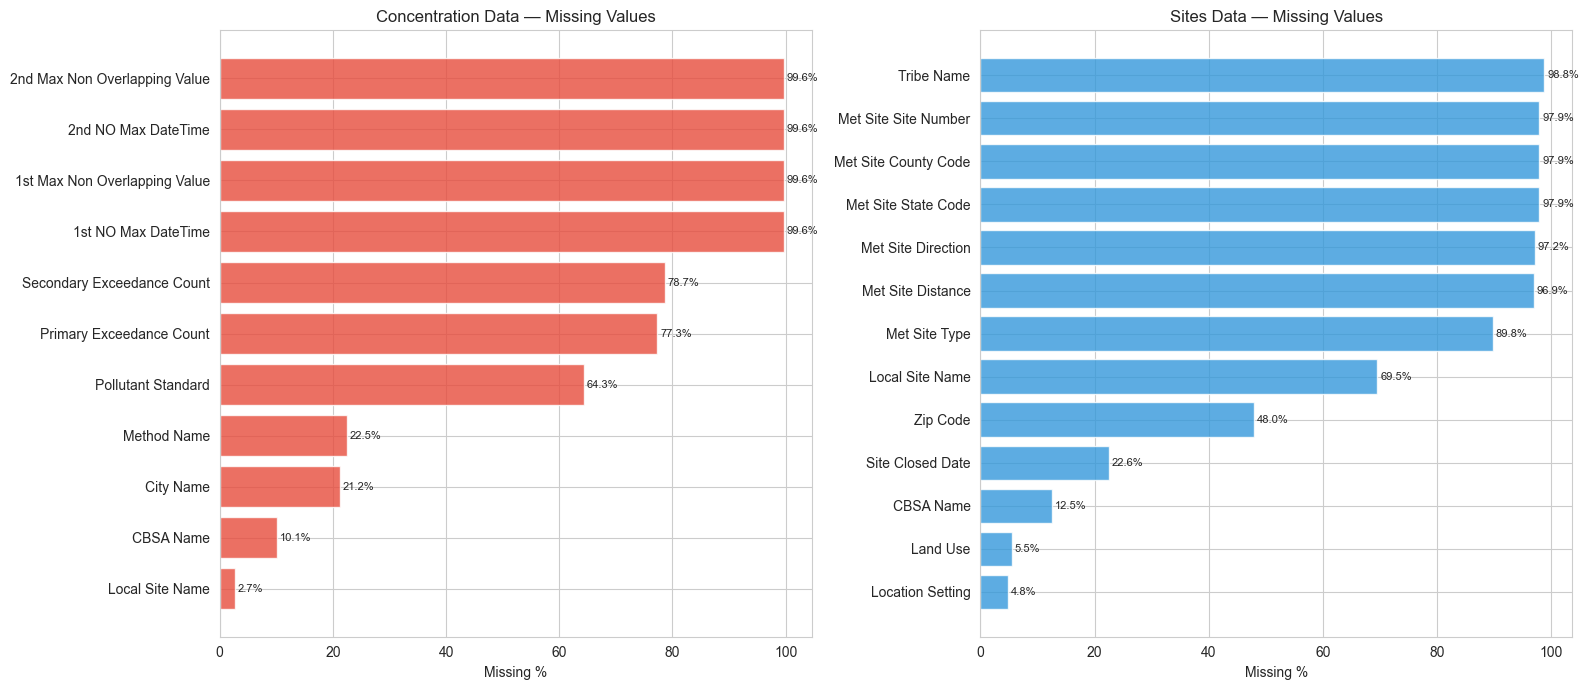

In [8]:
# Visualizing the missingness for columns with >1% missing
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

conc_plot = conc_miss_df[conc_miss_df['Percent'] > 1].sort_values('Percent')
axes[0].barh(conc_plot.index, conc_plot['Percent'], color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Missing %')
axes[0].set_title('Concentration Data — Missing Values')
for i, (idx, row) in enumerate(conc_plot.iterrows()):
    axes[0].text(row['Percent'] + 0.5, i, f"{row['Percent']:.1f}%", va='center', fontsize=8)

sites_plot = sites_miss_df[sites_miss_df['Percent'] > 1].sort_values('Percent')
axes[1].barh(sites_plot.index, sites_plot['Percent'], color='#3498db', alpha=0.8)
axes[1].set_xlabel('Missing %')
axes[1].set_title('Sites Data — Missing Values')
for i, (idx, row) in enumerate(sites_plot.iterrows()):
    axes[1].text(row['Percent'] + 0.5, i, f"{row['Percent']:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.show()

### What we found

A lot of the high-missingness columns make sense when you think about what they represent:

- **Non-overlapping max values** (99.6% missing) - these only apply to specific pollutant standards like 8-hour ozone. They're supposed to be empty for other pollutants.
- **Pollutant Standard** (64.3% missing) - many parameters (weather measurements, speciation data) don't have a NAAQS standard, so this field is blank by design.
- **Exceedance counts** (77 - 79% missing) - same idea, only applies to criteria pollutants.

The ones that actually concern us for our use case:
- **CBSA Name** is missing for 10.1% of concentration records, this limits metro-area comparisons
- **Method Name** missing for 22.5%, we can't check for method bias on those
- In the sites data, **Zip Code** (48%) and **Location Setting** (4.9% missing + some marked as UNKNOWN) limit how precisely we can classify sites geographically

---
## 2. Consistency

Can we actually join these two datasets together? Do the shared fields agree?

### 2.1 Joining the datasets

We need to fix the column name and type mismatches we spotted earlier. We'll create a standardized key (format: `SS-CCC-NNNN`) so the join is clean and traceable.

In [9]:
# Build a composite site key for both datasets
# Zero-padding so state '1' becomes '01', county '73' becomes '073', etc.

conc['site_key'] = (
    conc['State Code'].astype(str).str.zfill(2) + '-' +
    conc['County Code'].astype(str).str.zfill(3) + '-' +
    conc['Site Num'].astype(str).str.zfill(4)
)

sites['site_key'] = (
    sites['State Code'].astype(str).str.zfill(2) + '-' +
    sites['County Code'].astype(str).str.zfill(3) + '-' +
    sites['Site Number'].astype(str).str.zfill(4)
)

print(f"Sample key from concentration: {conc['site_key'].iloc[0]}")
print(f"Sample key from sites:         {sites['site_key'].iloc[0]}")

Sample key from concentration: 01-003-0010
Sample key from sites:         01-001-0001


In [10]:
# How well do these datasets overlap?
conc_keys = set(conc['site_key'].unique())
site_keys = set(sites['site_key'].unique())

print(f"Unique sites in concentration data: {len(conc_keys):,}")
print(f"Unique sites in sites metadata:     {len(site_keys):,}")
print(f"Matched (in both):                  {len(conc_keys & site_keys):,}")
print(f"In concentration but NOT in sites:   {len(conc_keys - site_keys):,}")
print(f"In sites but NOT in concentration:   {len(site_keys - conc_keys):,}")

Unique sites in concentration data: 2,246
Unique sites in sites metadata:     20,952
Matched (in both):                  2,246
In concentration but NOT in sites:   0
In sites but NOT in concentration:   18,706


In [11]:
# Verify with an actual merge
merged = pd.merge(conc, sites, on='site_key', how='left', indicator=True, suffixes=('_conc', '_sites'))
print(merged['_merge'].value_counts())

_merge
both          59154
left_only         0
right_only        0
Name: count, dtype: int64


All 2,246 sites in the concentration data matched to site metadata — no records lost. The 18,706 unmatched sites in the metadata are older or inactive monitors that don't have 2025 data.

### 2.2 Datum (coordinate reference system) consistency

Both datasets include lat/lon coordinates and a `Datum` field. If different datums are mixed together, geographic analysis could be slightly off.

In [12]:
print("Datum values in concentration data:")
print(conc['Datum'].value_counts())

print("\nDatum values in sites data:")
print(sites['Datum'].value_counts(dropna=False))

Datum values in concentration data:
Datum
WGS84    43934
NAD83    15220
Name: count, dtype: int64

Datum values in sites data:
Datum
WGS84      19077
NAD83       1003
NAD27        866
UNKNOWN        6
Name: count, dtype: int64


In [13]:
# Do matched sites have the same datum in both datasets?
datum_check = merged[['site_key', 'Datum_conc', 'Datum_sites']].drop_duplicates(subset='site_key')
datum_mismatch = datum_check[datum_check['Datum_conc'] != datum_check['Datum_sites']]

print(f"Sites with matching datum: {len(datum_check) - len(datum_mismatch):,}")
print(f"Sites with mismatched datum: {len(datum_mismatch):,}")

Sites with matching datum: 2,246
Sites with mismatched datum: 0


The concentration data uses two datums (WGS84 and NAD83), while the sites data has four (adding NAD27 and UNKNOWN). For our matched sites, the datums agree. The practical difference between WGS84 and NAD83 is sub-meter for US locations, so this shouldn't affect county-level analysis, but it's worth noting.

---
## 3. Validity

Are the concentration values themselves plausible? Are there any values that don't make physical sense?

In [14]:
print("Arithmetic Mean — summary stats:")
print(conc['Arithmetic Mean'].describe())

Arithmetic Mean — summary stats:
count    59154.000000
mean        30.966771
std        274.983466
min        -42.254777
25%          0.042462
50%          0.615807
75%          7.497826
max      27312.765742
Name: Arithmetic Mean, dtype: float64


In [15]:
# The minimum is negative — concentrations can't be below zero
neg_values = conc[conc['Arithmetic Mean'] < 0]
print(f"Records with negative concentration: {len(neg_values):,} ({len(neg_values)/len(conc)*100:.2f}%)")
print(f"\nWhich pollutants have negative values:")
print(neg_values['Parameter Name'].value_counts().head(10))

Records with negative concentration: 1,006 (1.70%)

Which pollutants have negative values:
Parameter Name
Cesium PM2.5 LC       137
Indium PM2.5 LC       136
Silver PM2.5 LC       126
Selenium PM2.5 LC      89
Rubidium PM2.5 LC      69
OC1 PM2.5 LC           55
Vanadium PM2.5 LC      49
Cerium PM2.5 LC        48
Sulfur dioxide         42
Strontium PM2.5 LC     39
Name: count, dtype: int64


In [16]:
print(f"Range of negative values: {neg_values['Arithmetic Mean'].min():.6f} to {neg_values['Arithmetic Mean'].max():.6f}")

Range of negative values: -42.254777 to -0.000005


The 1,006 negative values are all in trace metal speciation (Indium, Cesium, Silver, etc.). These are tiny negative numbers close to zero — they come from blank-subtraction during lab analysis, where the blank reading is slightly higher than the sample. This is a known artifact of the measurement method, not a data entry error.

They're still physically impossible though, so we'll need to handle them. The standard approach is to set them to zero or to half the method detection limit.

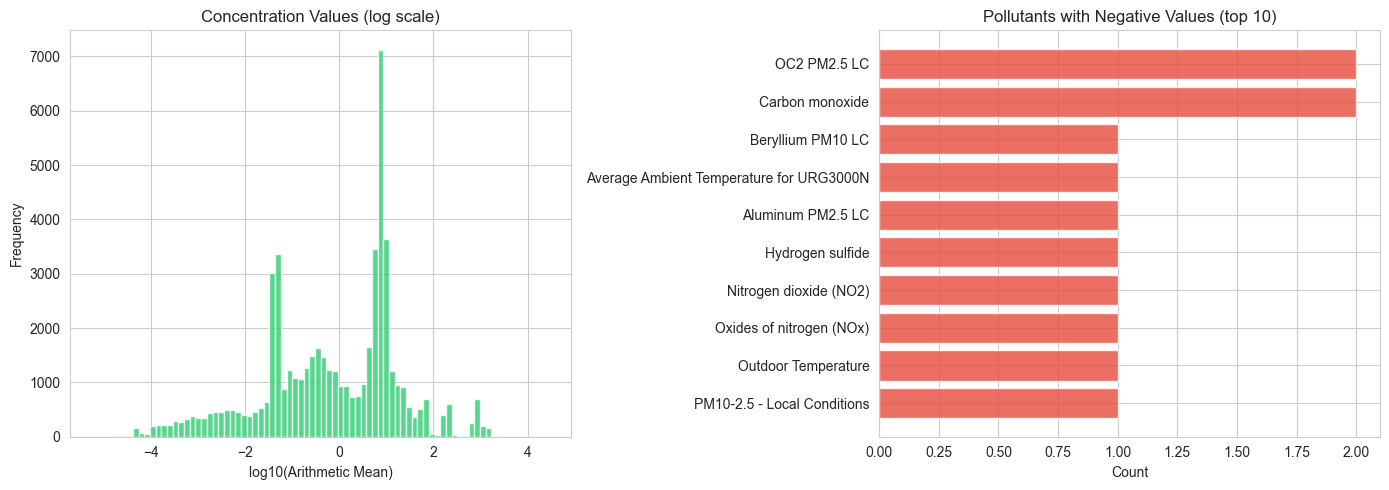

In [17]:
# Visualizing the concentration distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution on log scale (since values span many orders of magnitude)
positive = conc[conc['Arithmetic Mean'] > 0]['Arithmetic Mean']
axes[0].hist(np.log10(positive), bins=80, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('log10(Arithmetic Mean)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Concentration Values (log scale)')

# Negative values by parameter
neg_by_param = neg_values['Parameter Name'].value_counts().tail(10).sort_values()
axes[1].barh(neg_by_param.index, neg_by_param.values, color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Count')
axes[1].set_title('Pollutants with Negative Values (top 10)')

plt.tight_layout()
plt.show()

### 3.1 Observation completeness

Each record has an `Observation Percent` telling us what fraction of the year actually had measurements. EPA generally wants at least 75% for regulatory use.

In [18]:
print(conc['Observation Percent'].describe())

below_75 = (conc['Observation Percent'] < 75).sum()
print(f"\nRecords below 75% observation: {below_75:,} ({below_75/len(conc)*100:.1f}%)")

print(f"\nCompleteness Indicator breakdown:")
print(conc['Completeness Indicator'].value_counts())

count    59154.000000
mean        47.271782
std         21.849763
min          0.000000
25%         34.000000
50%         47.000000
75%         66.000000
max        100.000000
Name: Observation Percent, dtype: float64

Records below 75% observation: 52,880 (89.4%)

Completeness Indicator breakdown:
Completeness Indicator
N    55854
Y     3300
Name: count, dtype: int64


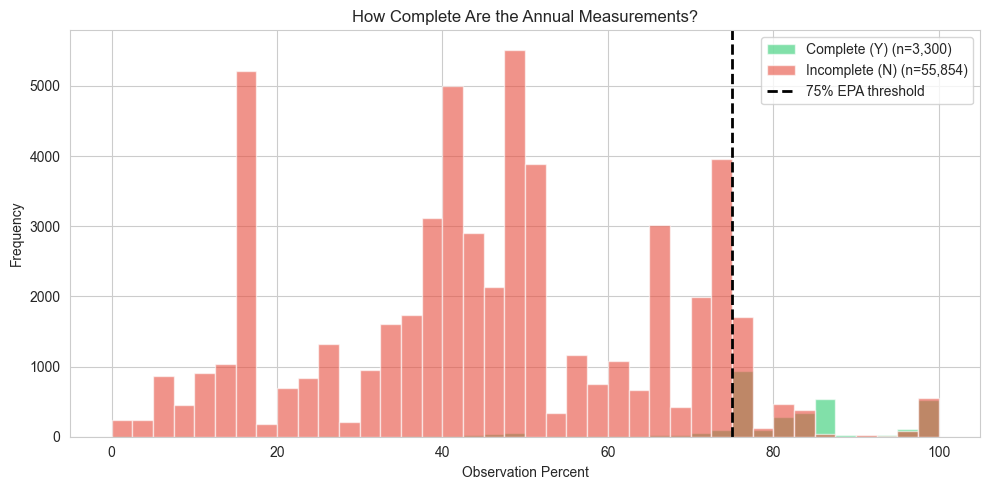

In [19]:
# How does observation percent differ between complete (Y) and incomplete (N) records?
fig, ax = plt.subplots(figsize=(10, 5))

for indicator, color, label in [('Y', '#2ecc71', 'Complete (Y)'), ('N', '#e74c3c', 'Incomplete (N)')]:
    subset = conc[conc['Completeness Indicator'] == indicator]['Observation Percent']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=f"{label} (n={len(subset):,})")

ax.axvline(x=75, color='black', linestyle='--', linewidth=2, label='75% EPA threshold')
ax.set_xlabel('Observation Percent')
ax.set_ylabel('Frequency')
ax.set_title('How Complete Are the Annual Measurements?')
ax.legend()
plt.tight_layout()
plt.show()

This is a big finding: **89.4% of records** fall below the 75% observation threshold, and only 5.6% have the `Y` completeness indicator. This is important for our use case because if we're comparing county averages, a county where monitors ran all year is not directly comparable to one where monitors only ran for a few months.

We're planning to flag these rather than remove them, and then do a sensitivity check showing how results change with and without the incomplete records.

### 3.2 Event type

Some records include or exclude exceptional events like wildfires and dust storms. This affects how we interpret the measurements.

In [20]:
print("Event Type breakdown:")
print(conc['Event Type'].value_counts())
print(f"\nRecords affected by events: {(conc['Event Type'] != 'No Events').sum():,} ({(conc['Event Type'] != 'No Events').mean()*100:.1f}%)")

Event Type breakdown:
Event Type
No Events                    57649
Events Included                878
Concurred Events Excluded      365
Events Excluded                262
Name: count, dtype: int64

Records affected by events: 1,505 (2.5%)


About 2.5% of records involve exceptional events. This connects to the uniqueness issue we'll look at next — the same measurement sometimes appears multiple times with different event handling.

---
## 4. Uniqueness

Are there duplicate records? If so, are they true duplicates or is there a reason for them?

In [21]:
# Check for exact row duplicates
print(f"Exact duplicate rows in concentration: {conc.duplicated().sum()}")
print(f"Exact duplicate rows in sites:         {sites.duplicated().sum()}")

Exact duplicate rows in concentration: 0
Exact duplicate rows in sites:         0


In [22]:
# Check for logical duplicates — same site/parameter/duration/standard combo
biz_key = ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Sample Duration', 'Pollutant Standard']
logical_dupes = conc[conc.duplicated(subset=biz_key, keep=False)].sort_values(biz_key)

print(f"Logical duplicates (same measurement key): {len(logical_dupes):,} records")

Logical duplicates (same measurement key): 992 records


In [23]:
# What's causing them?
print("Event Type in the duplicate records:")
print(logical_dupes['Event Type'].value_counts())

# Does adding Event Type resolve all duplicates?
biz_key_with_event = biz_key + ['Event Type']
remaining = conc.duplicated(subset=biz_key_with_event, keep=False).sum()
print(f"\nDuplicates remaining after including Event Type: {remaining}")

Event Type in the duplicate records:
Event Type
Events Included              365
Concurred Events Excluded    365
Events Excluded              262
Name: count, dtype: int64

Duplicates remaining after including Event Type: 0


In [24]:
# Show an example so we can see exactly what's happening
example = logical_dupes.iloc[0][biz_key].to_dict()
mask = pd.Series(True, index=conc.index)
for col, val in example.items():
    if pd.isna(val):
        mask &= conc[col].isna()
    else:
        mask &= (conc[col] == val)

print("Example — same measurement reported with different event handling:")
conc[mask][['State Name', 'County Name', 'Parameter Name', 'Event Type', 'Arithmetic Mean', 'Observation Count']]

Example — same measurement reported with different event handling:


,State Name,County Name,Parameter Name,Event Type,Arithmetic Mean,Observation Count
99,Alabama,Jefferson,PM2.5 - Local Conditions,Events Included,11.523749,4215
100,Alabama,Jefferson,PM2.5 - Local Conditions,Concurred Events Excluded,11.523749,4215


No true duplicates exist. The 992 "logical duplicates" are all cases where EPA reports the same measurement multiple times with different Event Type values (with events included, with events excluded, etc.). This is their standard reporting structure, not a data error.

But it's a trap for our analysis: if we aggregate without filtering Event Type first, we'd double-count these measurements in our county averages. We'll need to pick one Event Type per measurement before doing any aggregation.

---
## 5. Coverage

How evenly are monitoring stations distributed across the country? This matters because we're comparing pollution across counties — if some areas have way more monitors than others, the comparisons aren't equally reliable.

In [25]:
sites_per_state = conc.groupby('State Name')['site_key'].nunique().sort_values(ascending=False)

print(f"States/territories with monitoring data: {len(sites_per_state)}")
print(f"Most monitored:  {sites_per_state.index[0]} ({sites_per_state.iloc[0]} sites)")
print(f"Least monitored: {sites_per_state.index[-1]} ({sites_per_state.iloc[-1]} site)")
print(f"Median:          {sites_per_state.median():.0f} sites per state")

States/territories with monitoring data: 54
Most monitored:  California (219 sites)
Least monitored: Virgin Islands (1 site)
Median:          32 sites per state


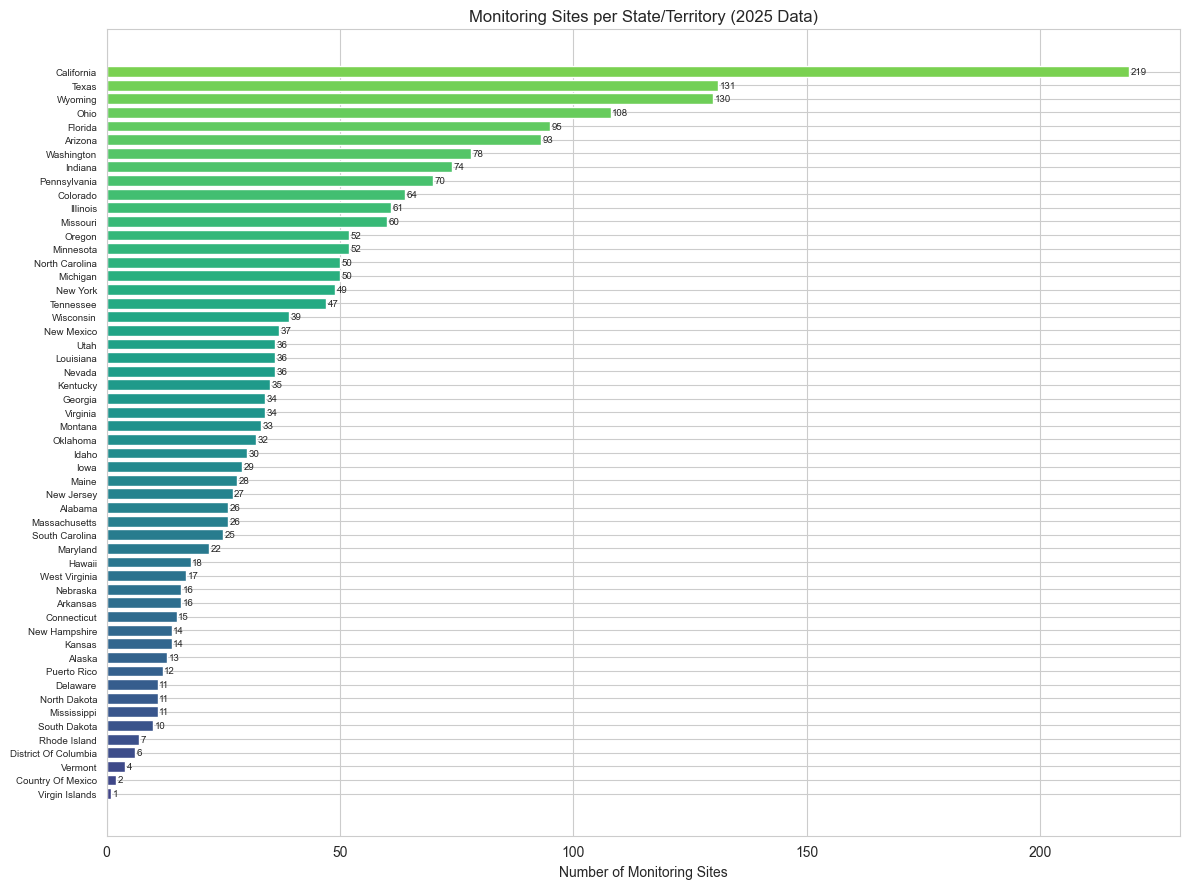

In [26]:
fig, ax = plt.subplots(figsize=(12, 9))
sites_per_state_sorted = sites_per_state.sort_values()
ax.barh(range(len(sites_per_state_sorted)), sites_per_state_sorted.values, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(sites_per_state_sorted))))
ax.set_yticks(range(len(sites_per_state_sorted)))
ax.set_yticklabels(sites_per_state_sorted.index, fontsize=7)
ax.set_xlabel('Number of Monitoring Sites')
ax.set_title('Monitoring Sites per State/Territory (2025 Data)')

for i, count in enumerate(sites_per_state_sorted.values):
    ax.text(count + 0.3, i, str(count), va='center', fontsize=7)

plt.tight_layout()
plt.show()

In [27]:
# What about location setting? (urban vs suburban vs rural)
active_sites = sites[sites['site_key'].isin(conc_keys)]

print("Location Setting for active 2025 sites:")
print(active_sites['Location Setting'].value_counts(dropna=False))

unknown_or_na = active_sites['Location Setting'].isna() | (active_sites['Location Setting'] == 'UNKNOWN')
print(f"\nSites with unknown/missing setting: {unknown_or_na.sum()} ({unknown_or_na.mean()*100:.1f}%)")

Location Setting for active 2025 sites:
Location Setting
RURAL                    930
SUBURBAN                 786
URBAN AND CENTER CITY    523
NaN                        7
Name: count, dtype: int64

Sites with unknown/missing setting: 7 (0.3%)


In [28]:
print("Land Use for active 2025 sites:")
print(active_sites['Land Use'].value_counts(dropna=False))

Land Use for active 2025 sites:
Land Use
RESIDENTIAL             792
COMMERCIAL              481
INDUSTRIAL              312
AGRICULTURAL            293
FOREST                  239
DESERT                   72
MOBILE                   36
NaN                      11
MILITARY RESERVATION      6
BLIGHTED AREAS            4
Name: count, dtype: int64


There's a 113x difference between the most-monitored state (California, 113 sites) and the least (Virgin Islands, 1 site). This is a structural limitation — we can't fix it through cleaning, but we need to acknowledge it when comparing county-level pollution numbers. A county with 10 monitors will give us a much more reliable average than one with a single monitor.

The location setting breakdown looks reasonable for the active sites, though a small percentage are UNKNOWN or missing.

---
## Summary of Findings So Far

Here's a consolidated view of everything we've detected, organized by our five quality dimensions.

In [29]:
summary = pd.DataFrame([
    ['Completeness', 'Non-overlapping max values missing (99.6%)', 'Structural — standard-specific fields', 'No action needed'],
    ['Completeness', 'Pollutant Standard missing (64.3%)', 'Expected for non-NAAQS parameters', 'Flag, not an error'],
    ['Completeness', 'CBSA Name missing (10.1%)', 'Limits metro-area comparisons', 'Try cross-referencing with site metadata'],
    ['Completeness', 'Method Name missing (22.5%)', 'Can\'t assess method bias', 'Flag for downstream filtering'],
    ['Consistency', 'Join key type mismatch (int vs str)', 'Would cause silent join failures', 'Harmonized to zero-padded strings'],
    ['Consistency', 'Column name mismatch (Site Num vs Site Number)', 'Join would fail', 'Used composite key approach'],
    ['Consistency', 'Mixed datums (WGS84, NAD83, NAD27, UNKNOWN)', 'Minor geographic ambiguity', 'Document — sub-meter impact'],
    ['Validity', 'Negative concentrations (1,006 records)', 'Physically impossible', 'Plan to set to 0 or half MDL'],
    ['Validity', 'Low observation completeness (89.4% below 75%)', 'Unreliable annual averages', 'Plan to flag and do sensitivity analysis'],
    ['Uniqueness', 'Event Type logical duplicates (992 records)', 'Double-counting risk', 'Plan to filter to one Event Type before aggregation'],
    ['Coverage', 'Geographic imbalance (113x ratio across states)', 'Uneven comparison confidence', 'Document — can\'t fix through cleaning'],
    ['Coverage', 'Unknown/missing Location Setting (~6%)', 'Can\'t classify urban vs rural', 'Flag as unclassified'],
], columns=['Dimension', 'Issue', 'Why It Matters', 'Planned Action'])

summary

,Dimension,Issue,Why It Matters,Planned Action
0,Completeness,Non-overlapping max values missing (99.6%),Structural — standard-specific fields,No action needed
1,Completeness,Pollutant Standard missing (64.3%),Expected for non-NAAQS parameters,"Flag, not an error"
2,Completeness,CBSA Name missing (10.1%),Limits metro-area comparisons,Try cross-referencing with site metadata
3,Completeness,Method Name missing (22.5%),Can't assess method bias,Flag for downstream filtering
4,Consistency,Join key type mismatch (int vs str),Would cause silent join failures,Harmonized to zero-padded strings
5,Consistency,Column name mismatch (Site Num vs Site Number),Join would fail,Used composite key approach
6,Consistency,"Mixed datums (WGS84, NAD83, NAD27, UNKNOWN)",Minor geographic ambiguity,Document — sub-meter impact
7,Validity,"Negative concentrations (1,006 records)",Physically impossible,Plan to set to 0 or half MDL
8,Validity,Low observation completeness (89.4% below 75%),Unreliable annual averages,Plan to flag and do sensitivity analysis
9,Uniqueness,Event Type logical duplicates (992 records),Double-counting risk,Plan to filter to one Event Type before aggreg...


---
## Next Steps

For the final submission, we plan to:

1. Implement the repair actions listed above (negative values, event type filtering)
2. Produce a cleaned intermediate dataset with quality flags preserved
3. Run before/after comparisons on county-level pollution summaries to show how cleaning decisions affect the results
4. Expand the analysis to specific criteria pollutants (PM2.5, Ozone)
5. Write up the final report documenting what changed, what didn't, and why

---